Running Gillespie simulations...
  Healthy (strong PQC)                 mean A(end) = 1.8
  Borderline (moderate PQC)            mean A(end) = 1141.1
  Disease (weak PQC)                   mean A(end) = 1198.1
  Disease (high production)            mean A(end) = 3591.9


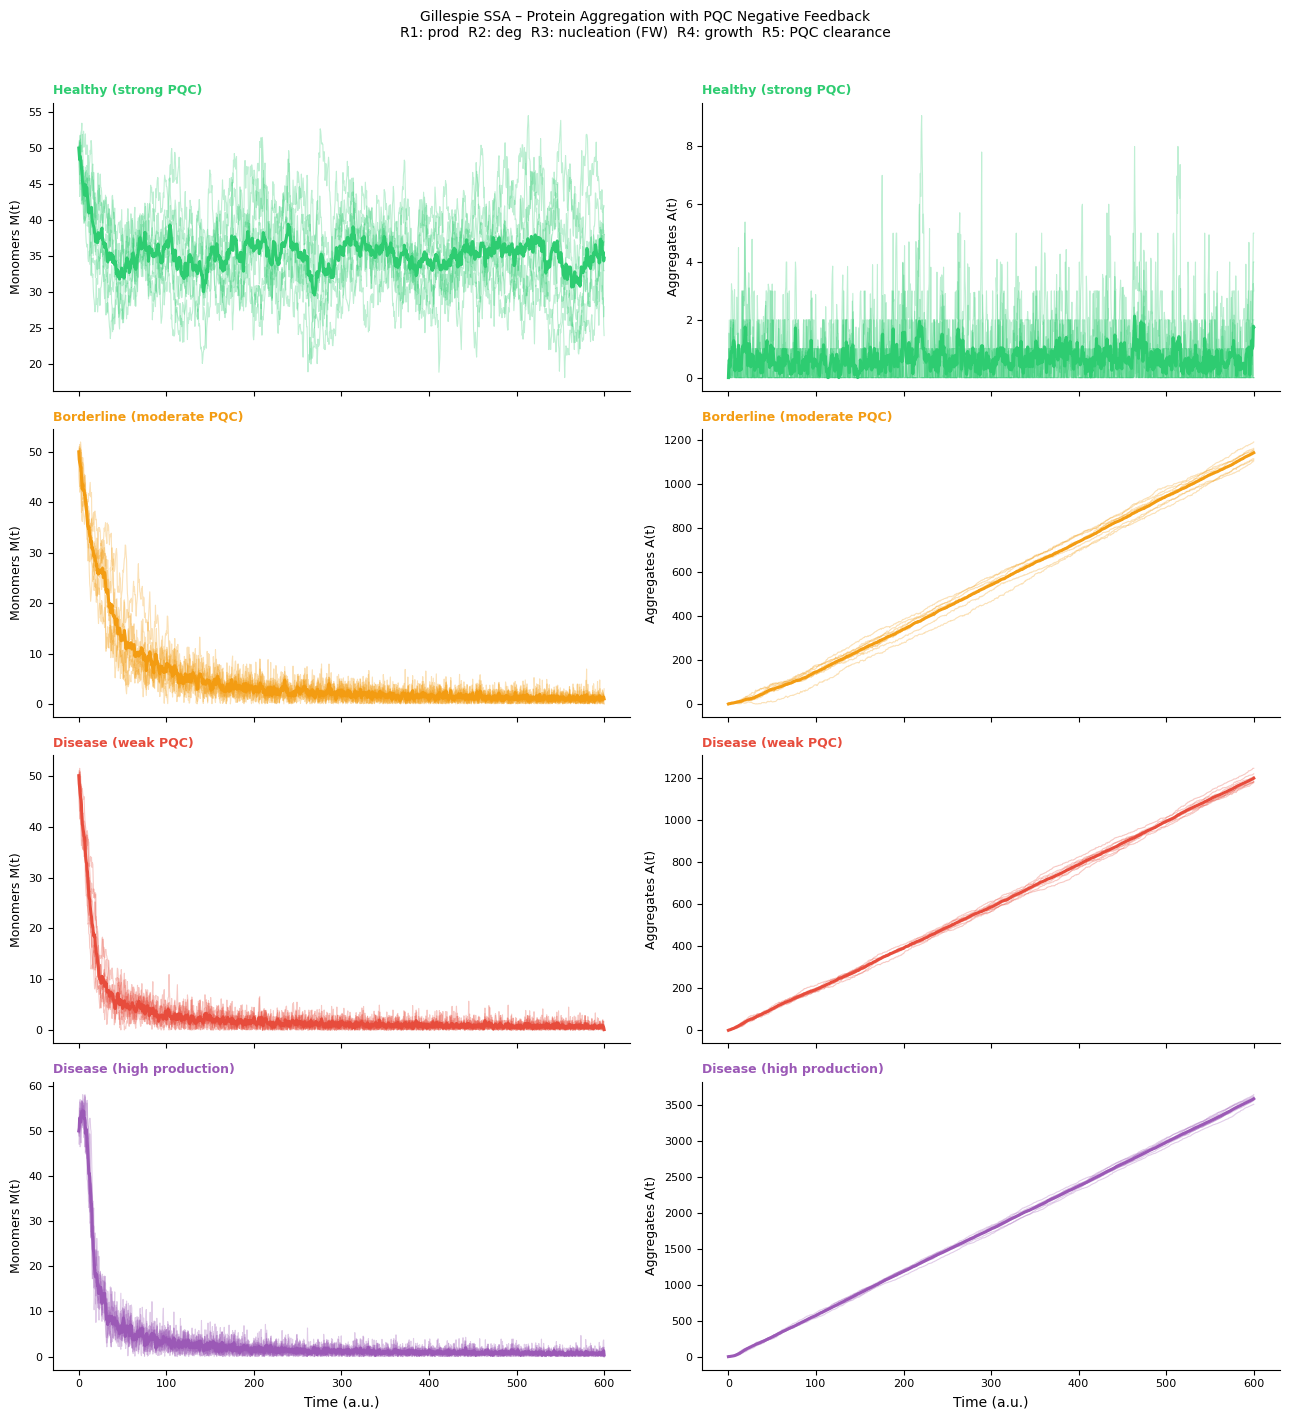

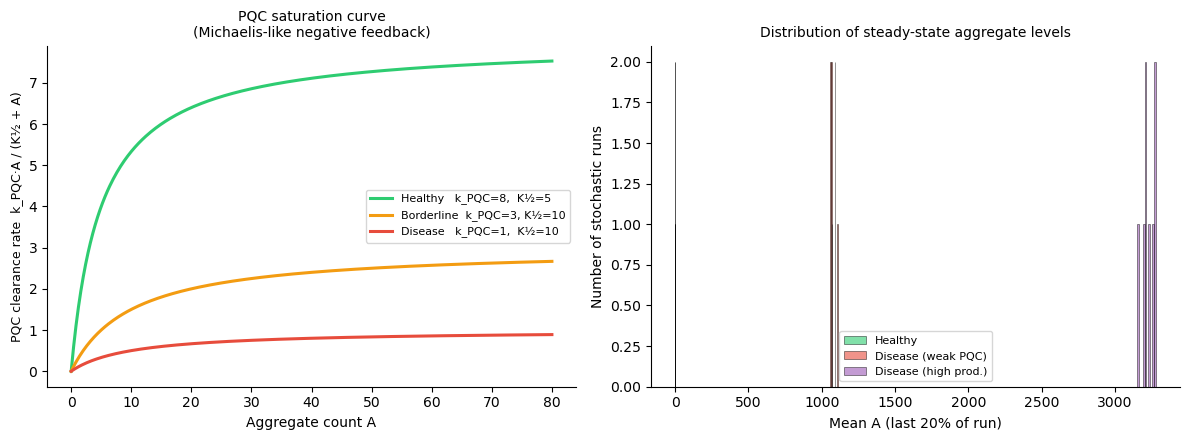

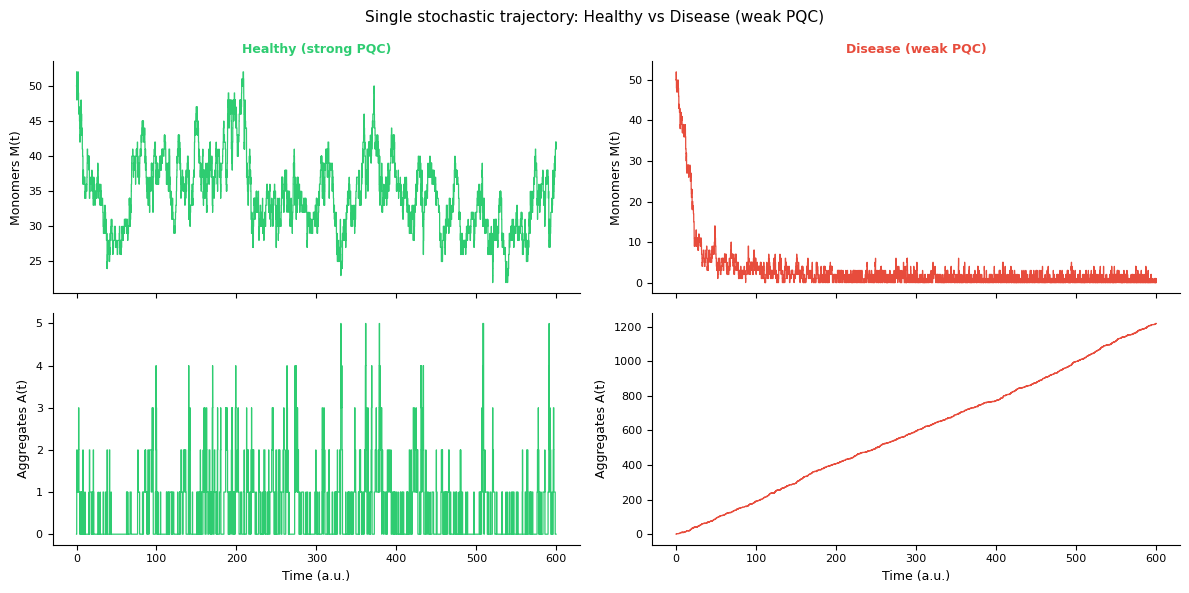


Computing phase diagram (takes ~30 sec)...


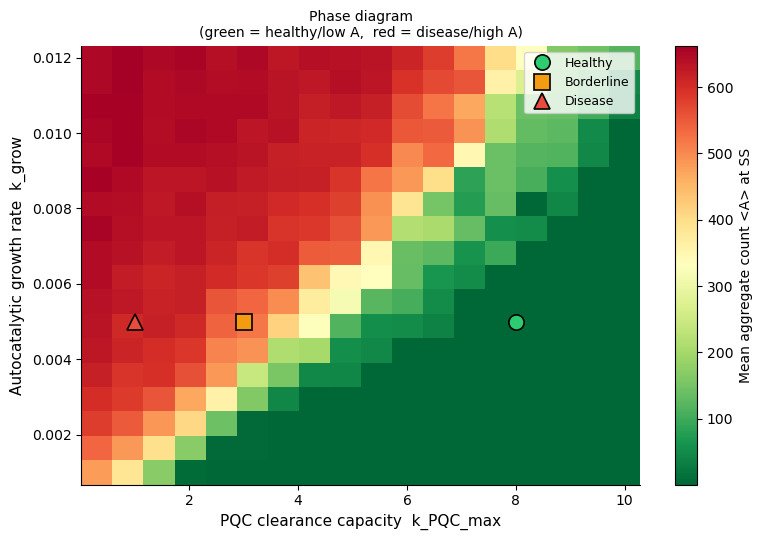


Key results summary:
───────────────────────────────────────────────────────
  Healthy (strong PQC)                 <M>= 35.0  <A>=  0.6
  Borderline (moderate PQC)            <M>=  1.1  <A>=1020.6
  Disease (weak PQC)                   <M>=  0.8  <A>=1076.3
  Disease (high production)            <M>=  0.8  <A>=3227.0
───────────────────────────────────────────────────────

Biology interpretation:
  Healthy   : strong PQC keeps <A> near 0  (low steady state ✓)
  Disease   : PQC saturates → positive feedback → run-away A

Where to intervene (lecture question):
  1. Increase k_PQC_max  → e.g. activate ABC transporters
                            (Krohn et al. 2011: thiethylperazine)
  2. Decrease k_grow     → block autocatalytic elongation
  3. Decrease k_prod     → reduce monomer production (siRNA)
  4. Reduce K_half       → keep PQC sensitive at low A levels
                            (prevent inhibition by insoluble aggregates)



In [3]:
"""
Week 2 – Physics of Molecular Diseases
Stochastic Gillespie simulation with PQC negative feedback
===========================================================

Paste this into a Jupyter cell (or split into multiple cells).
No savefig — uses plt.show() only.

Biology recap (from slides):
  - Misfolded monomers (M) nucleate and grow into aggregates (A).
  - PQC (chaperones / proteases / autophagy) inhibits aggregates.
  - Negative feedback loop:  A --> PQC --|  A
  - If A overwhelms PQC capacity, positive feedback takes over
    → run-away aggregation (disease state).

Reactions
---------
  R1: → M            k_prod              monomer production
  R2: M → 0          k_deg * M           basal degradation
  R3: 2M → A         k_nuc * M*(M-1)/2   nucleation (Finke-Watzky)
  R4: M+A → 2A       k_grow * M * A      autocatalytic growth
  R5: A → M          k_PQC_max*A/(K_half+A)   PQC clearance  ← KEY

PQC rate (R5) is Michaelis-like:
  - Low A  : rate ≈ linear  →  effective clearance
  - High A : rate saturates →  PQC overwhelmed, aggregates escape
"""

import numpy as np
import matplotlib.pyplot as plt

# ── Gillespie SSA ─────────────────────────────────────────────────────────────

def gillespie_PQC(params, t_max=500, seed=42):
    rng = np.random.default_rng(seed)

    k_prod    = params['k_prod']
    k_deg     = params['k_deg']
    k_nuc     = params['k_nuc']
    k_grow    = params['k_grow']
    k_PQC_max = params['k_PQC_max']
    K_half    = params['K_half']

    M = params.get('M0', 50)
    A = params.get('A0', 0)

    t = 0.0
    t_arr, M_arr, A_arr = [t], [M], [A]

    while t < t_max:
        a1 = k_prod
        a2 = k_deg * M
        a3 = k_nuc * M * (M - 1) / 2.0 if M >= 2 else 0.0
        a4 = k_grow * M * A
        a5 = k_PQC_max * A / (K_half + A) if A > 0 else 0.0

        a_total = a1 + a2 + a3 + a4 + a5
        if a_total == 0:
            break

        dt = rng.exponential(1.0 / a_total)
        t += dt
        if t > t_max:
            break

        r = rng.uniform(0, a_total)
        cum = 0.0
        cum += a1
        if r < cum:
            M += 1
        else:
            cum += a2
            if r < cum:
                M = max(0, M - 1)
            else:
                cum += a3
                if r < cum:
                    M = max(0, M - 2); A += 1
                else:
                    cum += a4
                    if r < cum:
                        M = max(0, M - 1); A += 1
                    else:
                        A = max(0, A - 1); M += 1

        t_arr.append(t); M_arr.append(M); A_arr.append(A)

    return np.array(t_arr), np.array(M_arr), np.array(A_arr)


def interp_grid(t_arr, x_arr, t_grid):
    return np.interp(t_grid, t_arr, x_arr)


# ── Parameter sets ────────────────────────────────────────────────────────────

BASE = dict(k_prod=2.0, k_deg=0.04, k_nuc=0.001, k_grow=0.005, M0=50, A0=0)

SCENARIOS = {
    "Healthy (strong PQC)": dict(
        **BASE, k_PQC_max=8.0, K_half=5.0,  color='#2ecc71'),
    "Borderline (moderate PQC)": dict(
        **BASE, k_PQC_max=3.0, K_half=10.0, color='#f39c12'),
    "Disease (weak PQC)": dict(
        **BASE, k_PQC_max=1.0, K_half=10.0, color='#e74c3c'),
    "Disease (high production)": dict(
        k_prod=6.0, k_deg=BASE['k_deg'], k_nuc=BASE['k_nuc'],
        k_grow=BASE['k_grow'], M0=BASE['M0'], A0=BASE['A0'],
        k_PQC_max=3.0, K_half=10.0,          color='#9b59b6'),
}

T_MAX  = 600
N_RUNS = 8
t_grid = np.linspace(0, T_MAX, 1200)

# ── Run simulations ───────────────────────────────────────────────────────────

print("Running Gillespie simulations...")
results = {}
for name, params in SCENARIOS.items():
    runs_M, runs_A = [], []
    for seed in range(N_RUNS):
        t_arr, M_arr, A_arr = gillespie_PQC(params, t_max=T_MAX, seed=seed)
        runs_M.append(interp_grid(t_arr, M_arr, t_grid))
        runs_A.append(interp_grid(t_arr, A_arr, t_grid))
    results[name] = dict(M=np.array(runs_M), A=np.array(runs_A),
                         color=params['color'])
    ss = np.mean(runs_A, axis=0)[-1]
    print(f"  {name:35s}  mean A(end) = {ss:.1f}")

# ── Figure 1 – All scenarios, M and A trajectories ───────────────────────────

fig1, axes = plt.subplots(len(SCENARIOS), 2,
                          figsize=(13, 3.5 * len(SCENARIOS)), sharex=True)
fig1.suptitle(
    "Gillespie SSA – Protein Aggregation with PQC Negative Feedback\n"
    "R1: prod  R2: deg  R3: nucleation (FW)  R4: growth  R5: PQC clearance",
    fontsize=10, y=1.01,
)

for row, (name, data) in enumerate(results.items()):
    ax_M, ax_A = axes[row, 0], axes[row, 1]
    col = data['color']
    for i in range(N_RUNS):
        ax_M.plot(t_grid, data['M'][i], color=col, alpha=0.3, lw=0.8)
        ax_A.plot(t_grid, data['A'][i], color=col, alpha=0.3, lw=0.8)
    ax_M.plot(t_grid, data['M'].mean(axis=0), color=col, lw=2.2, label='mean')
    ax_A.plot(t_grid, data['A'].mean(axis=0), color=col, lw=2.2, label='mean')
    ax_M.set_ylabel("Monomers M(t)", fontsize=9)
    ax_A.set_ylabel("Aggregates A(t)", fontsize=9)
    for ax in (ax_M, ax_A):
        ax.set_title(name, fontsize=9, color=col, fontweight='bold', loc='left')
        ax.tick_params(labelsize=8)
        ax.spines[['top','right']].set_visible(False)

axes[-1, 0].set_xlabel("Time (a.u.)", fontsize=10)
axes[-1, 1].set_xlabel("Time (a.u.)", fontsize=10)
fig1.tight_layout()
plt.show()

# ── Figure 2 – PQC saturation curve + SS histogram ───────────────────────────

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: PQC rate as function of aggregate count
A_vals = np.linspace(0, 80, 400)
ax_pqc = axes2[0]
for kp, kh, lbl, col in [
    (8.0,  5.0, 'Healthy   k_PQC=8,  K½=5',  '#2ecc71'),
    (3.0, 10.0, 'Borderline  k_PQC=3, K½=10', '#f39c12'),
    (1.0, 10.0, 'Disease   k_PQC=1,  K½=10',  '#e74c3c'),
]:
    ax_pqc.plot(A_vals, kp * A_vals / (kh + A_vals), color=col, lw=2.2, label=lbl)

ax_pqc.set_xlabel('Aggregate count A', fontsize=10)
ax_pqc.set_ylabel('PQC clearance rate  k_PQC·A / (K½ + A)', fontsize=9)
ax_pqc.set_title('PQC saturation curve\n(Michaelis-like negative feedback)', fontsize=10)
ax_pqc.legend(fontsize=8)
ax_pqc.spines[['top','right']].set_visible(False)

# Right: histogram of SS aggregate level
ax_hist = axes2[1]
cutoff = int(0.80 * len(t_grid))
for name, col, lbl in [
    ("Healthy (strong PQC)",       '#2ecc71', 'Healthy'),
    ("Disease (weak PQC)",         '#e74c3c', 'Disease (weak PQC)'),
    ("Disease (high production)",  '#9b59b6', 'Disease (high prod.)'),
]:
    A_ss = results[name]['A'][:, cutoff:].mean(axis=1)
    ax_hist.hist(A_ss, bins=10, color=col, alpha=0.6,
                 label=lbl, edgecolor='k', lw=0.5)

ax_hist.set_xlabel('Mean A (last 20% of run)', fontsize=10)
ax_hist.set_ylabel('Number of stochastic runs', fontsize=10)
ax_hist.set_title('Distribution of steady-state aggregate levels', fontsize=10)
ax_hist.legend(fontsize=8)
ax_hist.spines[['top','right']].set_visible(False)
fig2.tight_layout()
plt.show()

# ── Figure 3 – Single detailed trajectory: Healthy vs Disease ────────────────

fig3, axes3 = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
fig3.suptitle("Single stochastic trajectory: Healthy vs Disease (weak PQC)", fontsize=11)

for col_idx, (name, params) in enumerate([
    ("Healthy (strong PQC)", SCENARIOS["Healthy (strong PQC)"]),
    ("Disease (weak PQC)",   SCENARIOS["Disease (weak PQC)"]),
]):
    t_arr, M_arr, A_arr = gillespie_PQC(params, t_max=T_MAX, seed=0)
    c = params['color']
    axes3[0, col_idx].step(t_arr, M_arr, where='post', color=c, lw=0.9)
    axes3[0, col_idx].set_ylabel('Monomers M(t)', fontsize=9)
    axes3[0, col_idx].set_title(name, color=c, fontsize=9, fontweight='bold')
    axes3[1, col_idx].step(t_arr, A_arr, where='post', color=c, lw=0.9)
    axes3[1, col_idx].set_ylabel('Aggregates A(t)', fontsize=9)
    axes3[1, col_idx].set_xlabel('Time (a.u.)', fontsize=9)
    for ax in axes3[:, col_idx]:
        ax.spines[['top','right']].set_visible(False)
        ax.tick_params(labelsize=8)

fig3.tight_layout()
plt.show()

# ── Figure 4 – Phase diagram: k_PQC_max vs k_grow ────────────────────────────

print("\nComputing phase diagram (takes ~30 sec)...")
k_PQC_vals  = np.linspace(0.3, 10.0, 18)
k_grow_vals = np.linspace(0.001, 0.012, 18)
A_mean_ss   = np.zeros((len(k_grow_vals), len(k_PQC_vals)))
T_PHASE     = 350
t_gp        = np.linspace(0, T_PHASE, 700)

for gi, kg in enumerate(k_grow_vals):
    for pi, kp in enumerate(k_PQC_vals):
        p = dict(k_prod=BASE['k_prod'], k_deg=BASE['k_deg'],
                 k_nuc=BASE['k_nuc'], M0=BASE['M0'], A0=BASE['A0'],
                 k_grow=kg, k_PQC_max=kp, K_half=8.0)
        vals = []
        for seed in range(4):
            t_g, _, A_g = gillespie_PQC(p, t_max=T_PHASE, seed=seed)
            A_interp = interp_grid(t_g, A_g, t_gp)
            vals.append(A_interp[t_gp >= 0.8 * T_PHASE].mean())
        A_mean_ss[gi, pi] = np.mean(vals)

fig4, ax4 = plt.subplots(figsize=(8, 5.5))
im = ax4.pcolormesh(k_PQC_vals, k_grow_vals, A_mean_ss,
                    cmap='RdYlGn_r', shading='auto')
fig4.colorbar(im, ax=ax4, label='Mean aggregate count <A> at SS')
ax4.set_xlabel('PQC clearance capacity  k_PQC_max', fontsize=11)
ax4.set_ylabel('Autocatalytic growth rate  k_grow', fontsize=11)
ax4.set_title('Phase diagram\n(green = healthy/low A,  red = disease/high A)', fontsize=10)

# Mark the scenario points
for (kp, kg), mk, c, lb in zip(
    [(8.0,0.005),(3.0,0.005),(1.0,0.005)],
    ['o','s','^'],
    ['#2ecc71','#f39c12','#e74c3c'],
    ['Healthy','Borderline','Disease'],
):
    ax4.plot(kp, kg, mk, color=c, ms=11, mec='k', mew=1.2, label=lb, zorder=5)

ax4.legend(fontsize=9, loc='upper right')
ax4.spines[['top','right']].set_visible(False)
fig4.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────

print("\nKey results summary:")
print("─" * 55)
for name, data in results.items():
    A_ss = data['A'][:, int(0.8*len(t_grid)):].mean()
    M_ss = data['M'][:, int(0.8*len(t_grid)):].mean()
    print(f"  {name:35s}  <M>={M_ss:5.1f}  <A>={A_ss:5.1f}")
print("─" * 55)
print("""
Biology interpretation:
  Healthy   : strong PQC keeps <A> near 0  (low steady state ✓)
  Disease   : PQC saturates → positive feedback → run-away A

Where to intervene (lecture question):
  1. Increase k_PQC_max  → e.g. activate ABC transporters
                            (Krohn et al. 2011: thiethylperazine)
  2. Decrease k_grow     → block autocatalytic elongation
  3. Decrease k_prod     → reduce monomer production (siRNA)
  4. Reduce K_half       → keep PQC sensitive at low A levels
                            (prevent inhibition by insoluble aggregates)
""")